# Isolation Forest — Anomaly Detection Baseline
### EngineFaultDB Dataset

Isolation Forest is used as the baseline model for unsupervised fault detection.
Both models are trained on healthy engine data only and evaluated on a test set
where faults represent approximately 17% of samples, simulating a realistic
deployment scenario where anomalies are relatively rare.


In [2]:
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score,
    precision_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)

warnings.filterwarnings("ignore")

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

os.makedirs("../figures", exist_ok=True)
os.makedirs("../models",  exist_ok=True)


## 1 · Data Loading

In [3]:
dataset = pd.read_csv('../data/EngineFaultDB_Final.csv')
print(f"Dataset shape: {dataset.shape}")
print()
print(dataset['Fault'].value_counts())


Dataset shape: (55999, 15)

Fault
0    16000
2    15000
3    14001
1    10998
Name: count, dtype: int64


## 2 · Preprocessing

In [4]:
healthy_data  = dataset[dataset["Fault"] == 0].drop(columns=["Fault"])
healthy_input = healthy_data.values

healthy_train, healthy_test = train_test_split(
    healthy_input, test_size=0.2, random_state=SEED)

print(f"Train: {len(healthy_train)} | Test: {len(healthy_test)}")


Train: 12800 | Test: 3200


In [5]:
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler())
])

pipeline.fit(healthy_train)

train_transformed = pipeline.transform(healthy_train)
test_transformed  = pipeline.transform(healthy_test)


In [6]:
faulty_transformeddata  = pipeline.transform(
    dataset[dataset['Fault'] == 1].drop("Fault", axis=1).values)
faulty_transformeddata2 = pipeline.transform(
    dataset[dataset['Fault'] == 2].drop("Fault", axis=1).values)
faulty_transformeddata3 = pipeline.transform(
    dataset[dataset['Fault'] == 3].drop("Fault", axis=1).values)


## 3 · Realistic Test Set

Fault samples are subsampled to 200 per fault type (~17% overall fault rate),
reflecting real-world conditions where fault readings are relatively rare compared
to normal operation. Using all fault samples would create a test set that is over
90% faulty, which does not reflect realistic deployment conditions.


In [7]:
N_PER_FAULT = 200

np.random.seed(SEED)
idx1 = np.random.choice(len(faulty_transformeddata),  N_PER_FAULT, replace=False)
idx2 = np.random.choice(len(faulty_transformeddata2), N_PER_FAULT, replace=False)
idx3 = np.random.choice(len(faulty_transformeddata3), N_PER_FAULT, replace=False)

fault_sample1 = faulty_transformeddata[idx1]
fault_sample2 = faulty_transformeddata2[idx2]
fault_sample3 = faulty_transformeddata3[idx3]

all_test = np.vstack([
    test_transformed,
    fault_sample1,
    fault_sample2,
    fault_sample3
])

all_labels = np.array(
    [0] * len(test_transformed) +
    [1] * N_PER_FAULT +
    [1] * N_PER_FAULT +
    [1] * N_PER_FAULT
)

fault_rate = (N_PER_FAULT * 3) / len(all_labels)
print(f"Healthy:    {len(test_transformed)}")
print(f"Fault:      {N_PER_FAULT * 3}")
print(f"Fault rate: {fault_rate:.1%}")


Healthy:    3200
Fault:      600
Fault rate: 15.8%


## 4 · Model Training

In [8]:
iso = IsolationForest(
    n_estimators=1000,
    contamination=0.05,
    random_state=SEED
)

iso.fit(train_transformed)
print("Training complete ✓")


Training complete ✓


## 5 · Anomaly Scores

In [23]:
if_scores = -iso.decision_function(all_test)

scores_healthy = -iso.decision_function(test_transformed)
scores_fault1  = -iso.decision_function(fault_sample1)
scores_fault2  = -iso.decision_function(fault_sample2)
scores_fault3  = -iso.decision_function(fault_sample3)

print(f"Avg score - Healthy: {np.mean(scores_healthy):.6f}")
print(f"Avg score - Fault 1: {np.mean(scores_fault1):.6f}")
print(f"Avg score - Fault 2: {np.mean(scores_fault2):.6f}")
print(f"Avg score - Fault 3: {np.mean(scores_fault3):.6f}")
print()
for name, score in [("Fault 1", scores_fault1),
                    ("Fault 2", scores_fault2),
                    ("Fault 3", scores_fault3)]:
    diff = np.mean(score) - np.mean(scores_healthy)
    print(f"{name}: avg score {np.mean(score):.4f} (+{diff:.4f} above healthy mean)")

Avg score - Healthy: -0.055134
Avg score - Fault 1: 0.001935
Avg score - Fault 2: -0.011776
Avg score - Fault 3: -0.013049

Fault 1: avg score 0.0019 (+0.0571 above healthy mean)
Fault 2: avg score -0.0118 (+0.0434 above healthy mean)
Fault 3: avg score -0.0130 (+0.0421 above healthy mean)


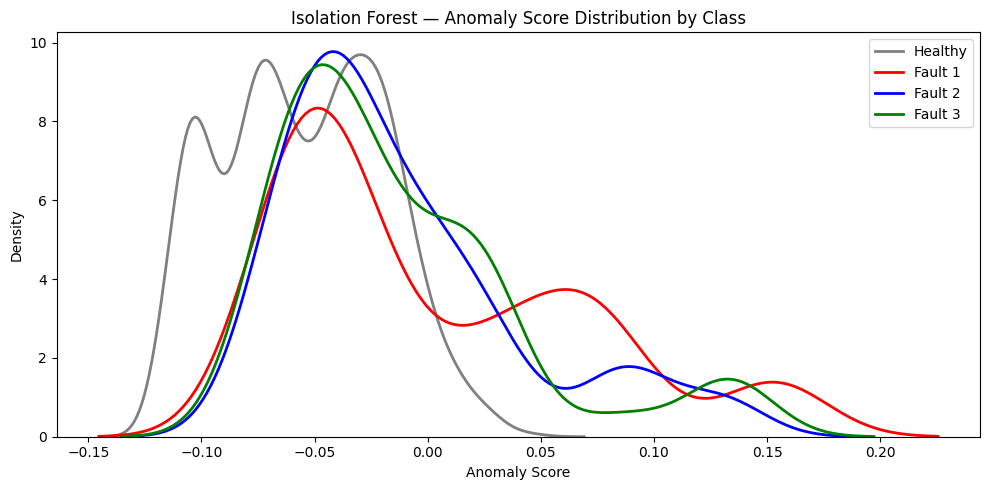

In [17]:
plt.figure(figsize=(10, 5))
for score, label, color in [
    (scores_healthy, "Healthy", "grey"),
    (scores_fault1,  "Fault 1", "red"),
    (scores_fault2,  "Fault 2", "blue"),
    (scores_fault3,  "Fault 3", "green"),
]:
    sns.kdeplot(score, label=label, color=color, linewidth=2)

plt.xlabel("Anomaly Score")
plt.title("Isolation Forest — Anomaly Score Distribution by Class")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/if_score_distribution.png", bbox_inches="tight")
plt.show()


## 6 · Threshold Optimization

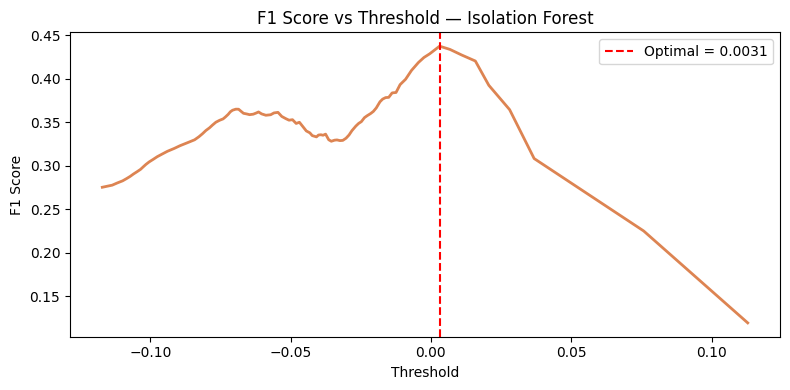

Optimal threshold: 0.0031
Best F1:           0.4374


In [18]:
# the baseline uses F1 for threshold optimization — balanced between precision and recall
thresholds_if = np.percentile(if_scores, np.arange(1, 100, 1))
f1_scores_if  = [f1_score(all_labels, (if_scores > t).astype(int))
                 for t in thresholds_if]

optimal_threshold_if = thresholds_if[np.argmax(f1_scores_if)]
preds_if             = (if_scores > optimal_threshold_if).astype(int)

plt.figure(figsize=(8, 4))
plt.plot(thresholds_if, f1_scores_if, color="#DD8452", linewidth=2)
plt.axvline(optimal_threshold_if, color="red", linestyle="--",
            label=f"Optimal = {optimal_threshold_if:.4f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold — Isolation Forest")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/if_threshold_optimization.png", bbox_inches="tight")
plt.show()

print(f"Optimal threshold: {optimal_threshold_if:.4f}")
print(f"Best F1:           {max(f1_scores_if):.4f}")


## 7 · Evaluation

In [19]:
roc_auc_if   = roc_auc_score(all_labels, if_scores)
f1_if        = f1_score(all_labels, preds_if)
recall_if    = recall_score(all_labels, preds_if)
precision_if = precision_score(all_labels, preds_if)

print("=== Isolation Forest Results ===")
print(f"ROC-AUC:   {roc_auc_if:.4f}")
print(f"F1:        {f1_if:.4f}")
print(f"Recall:    {recall_if:.4f}")
print(f"Precision: {precision_if:.4f}")


=== Isolation Forest Results ===
ROC-AUC:   0.7360
F1:        0.4374
Recall:    0.3433
Precision: 0.6023


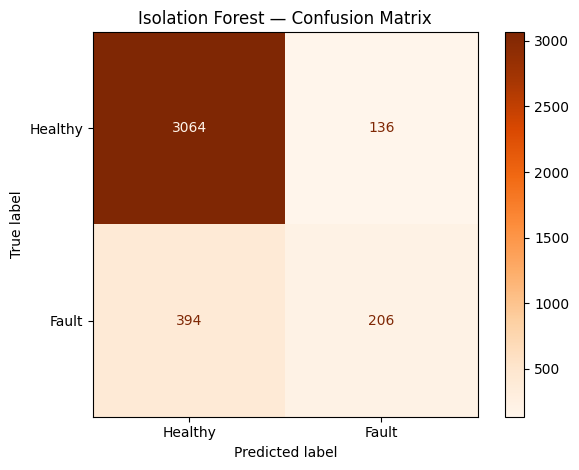

In [20]:
ConfusionMatrixDisplay(
    confusion_matrix(all_labels, preds_if),
    display_labels=["Healthy", "Fault"]
).plot(cmap="Oranges")
plt.title("Isolation Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("../figures/if_confusion_matrix.png", bbox_inches="tight")
plt.show()


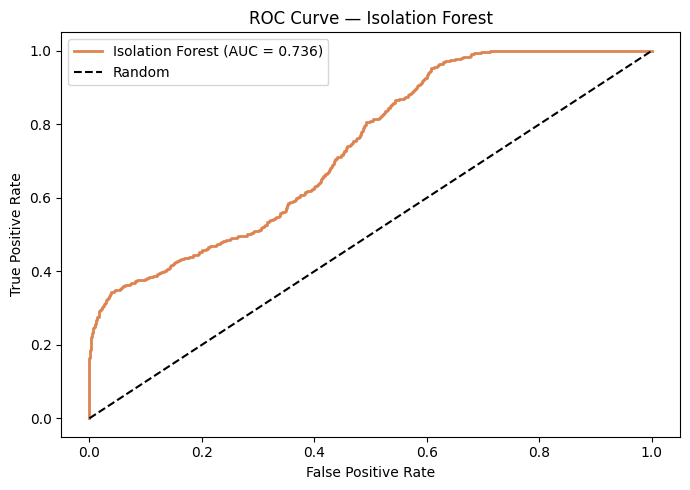

In [24]:
fpr_if, tpr_if, _ = roc_curve(all_labels, if_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr_if, tpr_if, color="#DD8452", linewidth=2,
         label=f"Isolation Forest (AUC = {roc_auc_if:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Isolation Forest")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/roc_curve_if.png", bbox_inches="tight")
plt.show()


In [22]:
joblib.dump(iso, "../models/isolation_forest.pkl")
print("Saved → ../models/isolation_forest.pkl")


Saved → ../models/isolation_forest.pkl
